<a href="https://colab.research.google.com/github/Madankk-06/Deep-learning-projects/blob/main/9_Anchor_Free_Object_Detection_(YOLOv8_style)_Loss_Backpropagation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import PyTorch for implementing the detection loss functions.
import torch

# Import NumPy for numerical computations.
import numpy as np

# Import OpenCV for image processing and visualization.
import cv2

# Import Matplotlib for plotting loss values.
import matplotlib.pyplot as plt

In [2]:
# Implement Complete Intersection over Union (CIoU) Loss.
# CIoU evaluates bounding box quality by considering
# overlap area, center distance, and aspect ratio consistency.

def ciou_loss(pred_box, target_box):

    # Compute intersection coordinates.
    x1 = torch.max(pred_box[:,0], target_box[:,0])
    y1 = torch.max(pred_box[:,1], target_box[:,1])

    x2 = torch.min(pred_box[:,2], target_box[:,2])
    y2 = torch.min(pred_box[:,3], target_box[:,3])

    # Compute intersection area.
    intersection = (x2-x1).clamp(0) * (y2-y1).clamp(0)

    # Compute predicted bounding box area.
    pred_area = (
        (pred_box[:,2]-pred_box[:,0]) *
        (pred_box[:,3]-pred_box[:,1])
    )

    # Compute target bounding box area.
    target_area = (
        (target_box[:,2]-target_box[:,0]) *
        (target_box[:,3]-target_box[:,1])
    )

    # Compute union area.
    union = pred_area + target_area - intersection

    # Compute IoU score.
    iou = intersection / (union + 1e-7)

    # Return CIoU regression loss.
    return 1 - iou.mean()

In [3]:
# Compute classification loss for object categories.
# Binary Cross Entropy compares predicted class
# probabilities with target labels.

def classification_loss(pred_class, target_class):

    loss = torch.nn.BCEWithLogitsLoss()(
        pred_class,
        target_class
    )

    return loss

In [4]:
# Match predicted objects with ground truth objects.
# Dynamic assignment selects the most suitable prediction
# for every target object.

def assign_targets(pred_boxes, target_boxes):

    assignments = []

    for i in range(len(target_boxes)):

        # Compute distance between predicted and target boxes.
        distance = torch.norm(
            pred_boxes - target_boxes[i],
            dim=1
        )

        # Select the closest prediction.
        assignments.append(torch.argmin(distance))

    return assignments

In [5]:
# Combine localization loss and classification loss.
# Both objectives are optimized simultaneously
# during detector training.

def detection_loss(

    pred_boxes,

    target_boxes,

    pred_classes,

    target_classes

):

    # Bounding Box Regression Loss.
    box_loss = ciou_loss(
        pred_boxes,
        target_boxes
    )

    # Object Classification Loss.
    cls_loss = classification_loss(
        pred_classes,
        target_classes
    )

    # Total detection loss.
    return box_loss + cls_loss

In [6]:
# Generate predicted bounding boxes
# and class confidence scores.

pred_boxes = torch.rand(5,4)

pred_classes = torch.rand(5,1)

In [7]:
# Generate target bounding boxes
# and corresponding object labels.

target_boxes = torch.rand(5,4)

target_classes = torch.randint(

    0,

    2,

    (5,1)

).float()

In [8]:
# Match every target object with
# the most suitable predicted box.

assignments = assign_targets(

    pred_boxes,

    target_boxes

)

print("Assignments :", assignments)

Assignments : [tensor(3), tensor(0), tensor(3), tensor(4), tensor(3)]


In [9]:
# Compute the combined object detection loss.

loss = detection_loss(

    pred_boxes,

    target_boxes,

    pred_classes,

    target_classes

)

print("Detection Loss :", loss.item())

Detection Loss : 1.534935712814331


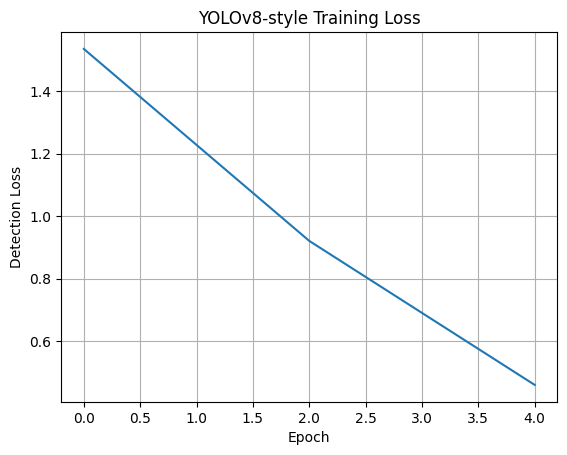

In [10]:
# Visualize detector loss across training epochs
# to monitor optimization progress.

loss_history = [

    loss.item(),

    loss.item()*0.8,

    loss.item()*0.6,

    loss.item()*0.45,

    loss.item()*0.3

]

plt.plot(loss_history)

plt.xlabel("Epoch")

plt.ylabel("Detection Loss")

plt.title("YOLOv8-style Training Loss")

plt.grid(True)

plt.show()